# Credit Card Fraud Detection


In [225]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")

OUTPUT_DIR = "model_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(name):
    plt.savefig(os.path.join(OUTPUT_DIR, name), bbox_inches="tight", dpi=300)

## Load data and inspect class balance

In [226]:
df = pd.read_csv("creditcard.csv")
display(df.head())
print(df["Class"].value_counts(normalize=True).rename("proportion"))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


## Quick exploratory plots

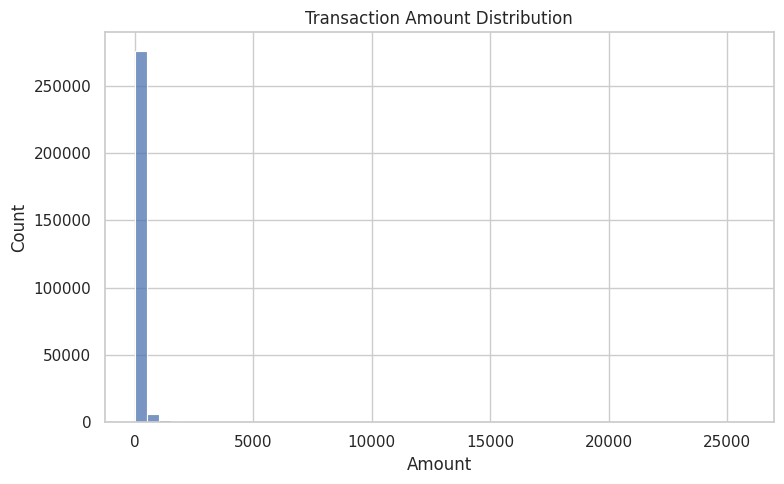

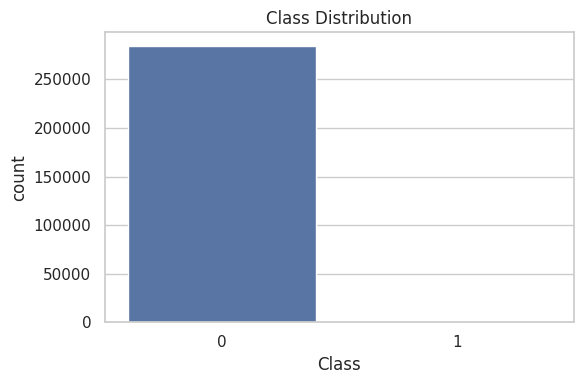

In [227]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.tight_layout()
save_fig("amount_histogram.png")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.tight_layout()
save_fig("class_countplot.png")
plt.show()

## Prepare features and split data

In [228]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

feature_names = list(X.columns)
print(X_train.shape, X_test.shape)

(227845, 30) (56962, 30)


## Train the models

In [229]:
scaler = StandardScaler()

# Scale inputs for the linear model
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    min_samples_leaf=2,
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Baseline evaluation at the default threshold

In [230]:
lr_pred_default = lr_model.predict(X_test_scaled)
rf_pred_default = rf_model.predict(X_test)

model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Precision": precision_score(y_test, lr_pred_default, zero_division=0),
        "Recall": recall_score(y_test, lr_pred_default, zero_division=0),
        "F1": f1_score(y_test, lr_pred_default, zero_division=0),
    },
    {
        "Model": "Random Forest",
        "Precision": precision_score(y_test, rf_pred_default, zero_division=0),
        "Recall": recall_score(y_test, rf_pred_default, zero_division=0),
        "F1": f1_score(y_test, rf_pred_default, zero_division=0),
    },
])

display(model_comparison)

print("Logistic Regression confusion matrix:")
print(confusion_matrix(y_test, lr_pred_default))
print(classification_report(y_test, lr_pred_default, zero_division=0))

print("\nRandom Forest confusion matrix:")
print(confusion_matrix(y_test, rf_pred_default))
print(classification_report(y_test, rf_pred_default, zero_division=0))

,Model,Precision,Recall,F1
0,Logistic Regression,0.060976,0.918367,0.114358
1,Random Forest,0.950000,0.775510,0.853933


Logistic Regression confusion matrix:
[[55478  1386]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Random Forest confusion matrix:
[[56860     4]
 [   22    76]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.78      0.85        98

    accuracy                           1.00     56962
   macro avg       0.97      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



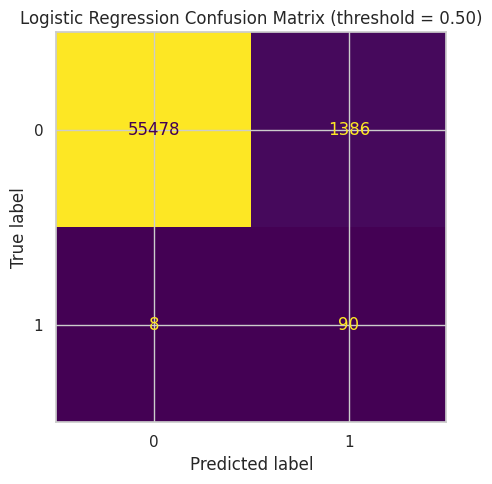

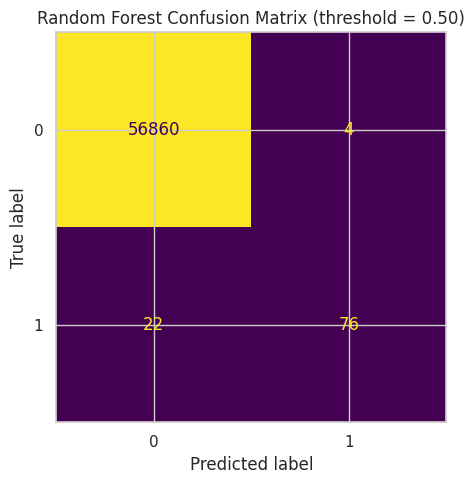

In [231]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, lr_pred_default)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=False)
plt.title("Logistic Regression Confusion Matrix (threshold = 0.50)")
plt.tight_layout()
save_fig("lr_confusion_default.png")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_pred_default)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=False)
plt.title("Random Forest Confusion Matrix (threshold = 0.50)")
plt.tight_layout()
save_fig("rf_confusion_default.png")
plt.show()

## Threshold sweep for logistic regression

In [232]:
y_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

def evaluate_threshold(threshold):
    preds = (y_probs >= threshold).astype(int)
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    print(f"Threshold: {threshold:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print("-" * 30)

for t in [0.1, 0.3, 0.5, 0.7, 0.9, 0.9983, 1.0]:
    evaluate_threshold(t)

Threshold: 0.1000
Precision: 0.0082
Recall: 0.9490
F1: 0.0162
------------------------------
Threshold: 0.3000
Precision: 0.0273
Recall: 0.9184
F1: 0.0531
------------------------------
Threshold: 0.5000
Precision: 0.0610
Recall: 0.9184
F1: 0.1144
------------------------------
Threshold: 0.7000
Precision: 0.1213
Recall: 0.9082
F1: 0.2139
------------------------------
Threshold: 0.9000
Precision: 0.2472
Recall: 0.8878
F1: 0.3867
------------------------------
Threshold: 0.9983
Precision: 0.6484
Recall: 0.8469
F1: 0.7345
------------------------------
Threshold: 1.0000
Precision: 0.8103
Recall: 0.4796
F1: 0.6026
------------------------------


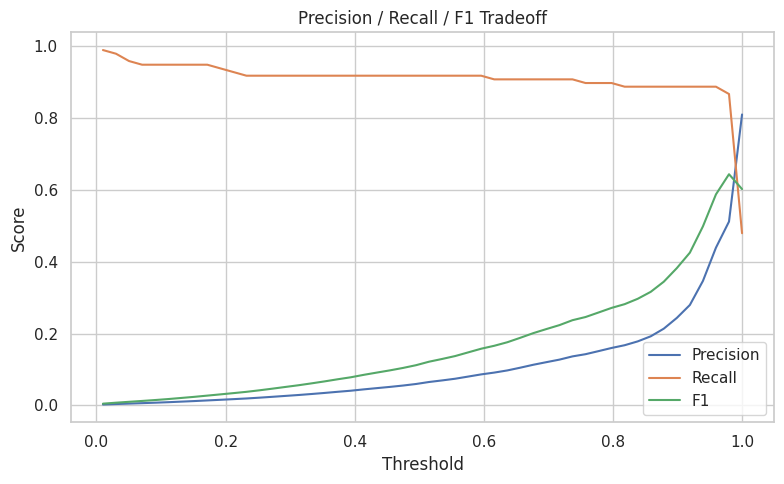

Best threshold: 0.9798


In [233]:
thresholds = np.linspace(0.01, 1.0, 50)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (y_probs >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))

best_idx = int(np.argmax(f1s))
best_threshold = float(thresholds[best_idx])

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 Tradeoff")
plt.legend()
plt.tight_layout()
save_fig("threshold_tradeoff.png")
plt.show()

print(f"Best threshold: {best_threshold:.4f}")

Best threshold: 0.9797959183673469
Precision: 0.5120481927710844
Recall: 0.8673469387755102
F1: 0.6439393939393939
[[56783    81]
 [   13    85]]


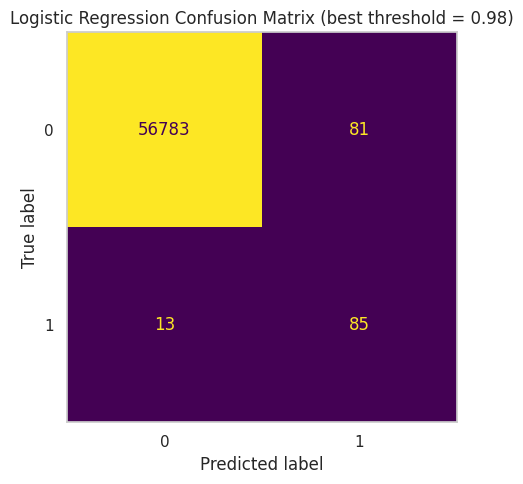

Random forest best threshold: 0.9797959183673469
Precision: 0.9565217391304348
Recall: 0.22448979591836735
F1: 0.36363636363636365
[[56863     1]
 [   76    22]]


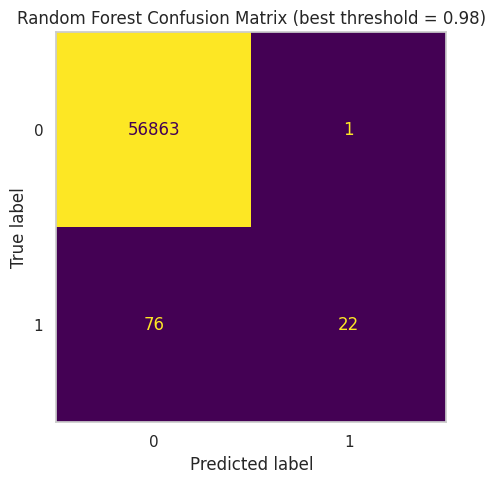

In [241]:
best_preds = (y_probs >= best_threshold).astype(int)

print("Best threshold:", best_threshold)
print("Precision:", precision_score(y_test, best_preds, zero_division=0))
print("Recall:", recall_score(y_test, best_preds, zero_division=0))
print("F1:", f1_score(y_test, best_preds, zero_division=0))
print(confusion_matrix(y_test, best_preds))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(
    ax=ax,
    colorbar=False,
    cmap="viridis",
    values_format="d",
    im_kw={"interpolation": "nearest"}
)

ax.grid(False)  # removes gray lines
plt.title(f"Logistic Regression Confusion Matrix (best threshold = {best_threshold:.2f})")
plt.tight_layout()
save_fig("lr_confusion_best_threshold.png")
plt.show()

# Random forest at the same best threshold

rf_y_probs = rf_model.predict_proba(X_test)[:, 1]
rf_best_preds = (rf_y_probs >= best_threshold).astype(int)

print("Random forest best threshold:", best_threshold)
print("Precision:", precision_score(y_test, rf_best_preds, zero_division=0))
print("Recall:", recall_score(y_test, rf_best_preds, zero_division=0))
print("F1:", f1_score(y_test, rf_best_preds, zero_division=0))
print(confusion_matrix(y_test, rf_best_preds))

fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(ax=ax, colorbar=False, cmap="viridis", values_format="d", im_kw={"interpolation": "nearest"})
ax.grid(False)
plt.title(f"Random Forest Confusion Matrix (best threshold = {best_threshold:.2f})")
plt.tight_layout()
save_fig("rf_confusion_best_threshold.png")
plt.show()

## Feature importance

Most positive logistic-regression coefficients:
V23       0.308435
V28       0.338464
V3        0.505718
V11       0.518715
V22       0.602374
V2        0.932075
V5        1.214379
V4        1.339431
V1        1.723862
Amount    2.367276

Most negative logistic-regression coefficients:
V14   -1.494961
V10   -1.334996
V12   -1.127886
V16   -0.996376
V17   -0.992185
V20   -0.927469
V7    -0.833570
V6    -0.696494
V8    -0.583326
V9    -0.529469

Top random-forest features:
V14    0.163791
V10    0.119701
V4     0.116264
V12    0.098064
V17    0.083295
V11    0.065944
V3     0.055741
V16    0.050197
V7     0.028830
V2     0.026360


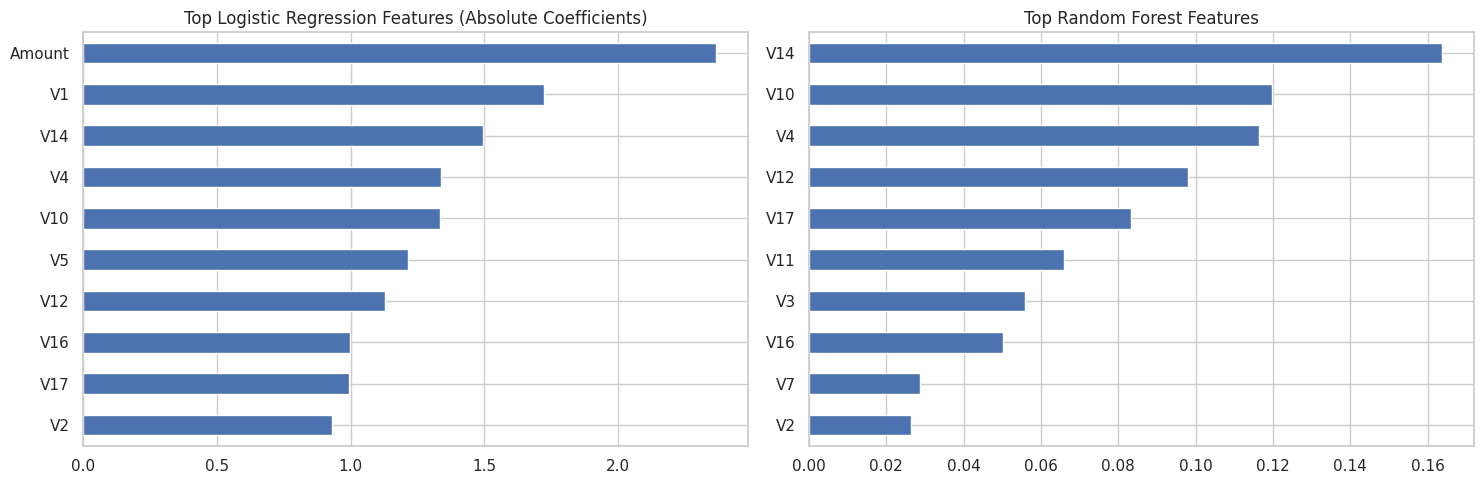

In [235]:
lr_signed = pd.Series(lr_model.coef_[0], index=feature_names).sort_values()
lr_importance = lr_signed.abs().sort_values(ascending=False)
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

print("Most positive logistic-regression coefficients:")
print(lr_signed.tail(10).to_string())
print()
print("Most negative logistic-regression coefficients:")
print(lr_signed.head(10).to_string())
print()
print("Top random-forest features:")
print(rf_importance.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
lr_importance.head(10).sort_values().plot(kind="barh", ax=axes[0], title="Top Logistic Regression Features (Absolute Coefficients)")
rf_importance.head(10).sort_values().plot(kind="barh", ax=axes[1], title="Top Random Forest Features")
plt.tight_layout()
save_fig("feature_importance.png")
plt.show()

## Two held-out test cases

In [236]:
# one legitimate example and one fraud example from the held-out test set
legit_idx = y_test[y_test == 0].index[0]
fraud_idx = y_test[y_test == 1].index[0]

test_case_features = X_test.loc[[legit_idx, fraud_idx]].copy()
test_case_labels = y_test.loc[[legit_idx, fraud_idx]].copy()

lr_case_probs = lr_model.predict_proba(scaler.transform(test_case_features))[:, 1]
rf_case_probs = rf_model.predict_proba(test_case_features)[:, 1]

test_case_results = pd.DataFrame({
    "Actual_Class": test_case_labels.values,
    "Logistic_Prob": lr_case_probs,
    f"Logistic_Pred_at_{best_threshold:.2f}": (lr_case_probs >= best_threshold).astype(int),
    "RandomForest_Prob": rf_case_probs,
    "RandomForest_Pred_at_0.50": (rf_case_probs >= 0.5).astype(int),
}, index=["Legit example", "Fraud example"])

display(test_case_results)

print("\nRaw feature values for the selected test cases:")
display(test_case_features)

,Actual_Class,Logistic_Prob,Logistic_Pred_at_0.98,RandomForest_Prob,RandomForest_Pred_at_0.50
Legit example,0,0.005691,0,0.000000,0
Fraud example,1,1.000000,1,0.953188,1



Raw feature values for the selected test cases:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
263020,160760.0,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,0.394322,0.080084,0.810034,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,23.00
77348,57007.0,-1.271244,2.462675,-2.851395,2.324480,-1.372245,-0.948196,-3.065234,1.166927,-2.268771,...,0.560478,0.652941,0.081931,-0.221348,-0.523582,0.224228,0.756335,0.632800,0.250187,0.01


## SHAP explanations

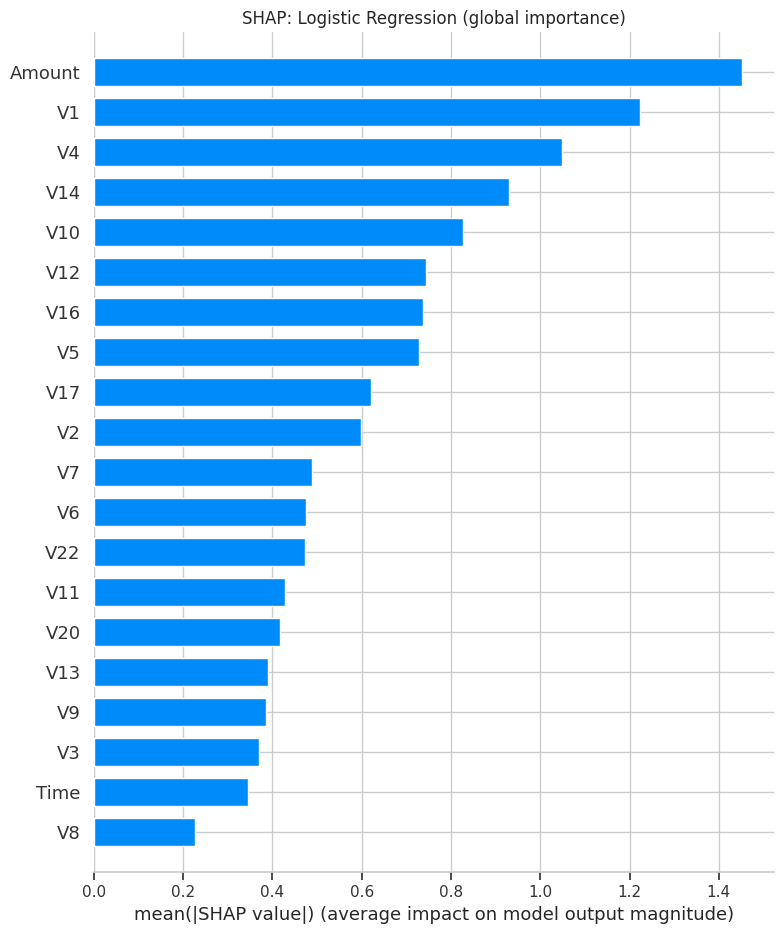

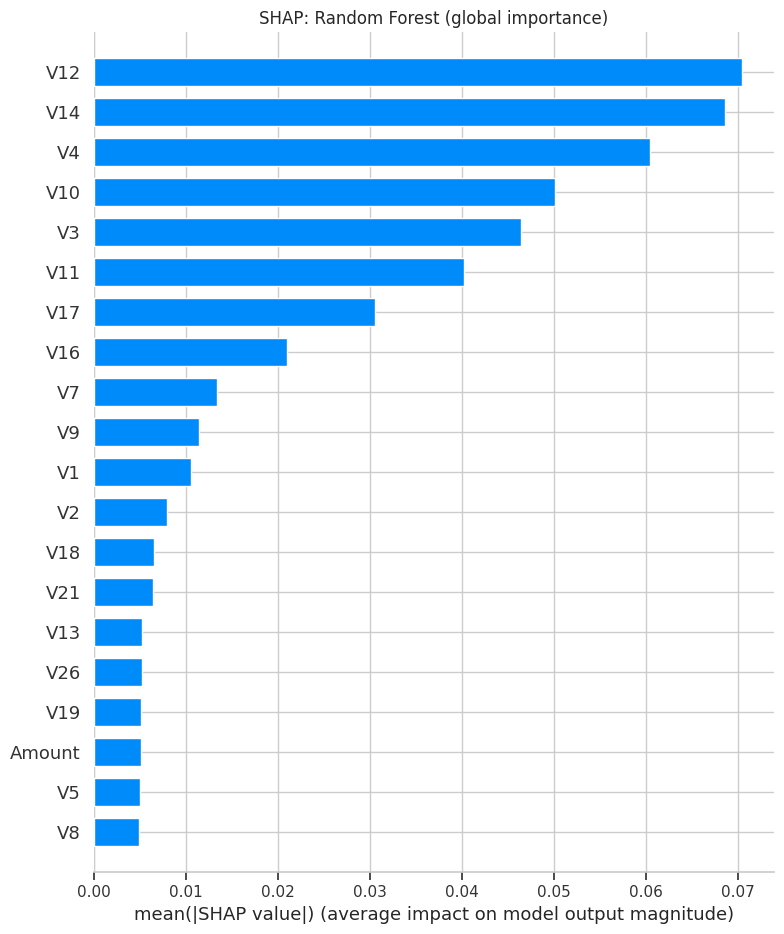


=== SHAP explanation for 263020 ===
Actual class: 0
Logistic regression probability: 0.005691
Random forest probability: 0.000000

Raw feature values:
Time      160760.000000
V1            -0.674466
V2             1.408105
V3            -1.110622
V4            -1.328366
V5             1.388996
V6            -1.308439
V7             1.885879
V8            -0.614233
V9             0.311652
V10            0.650757
V11           -0.857785
V12           -0.229961
V13           -0.199817
V14            0.266371
V15           -0.046544
V16           -0.741398
V17           -0.605617
V18           -0.392568
V19           -0.162648
V20            0.394322
V21            0.080084
V22            0.810034
V23           -0.224327
V24            0.707899
V25           -0.135837
V26            0.045102
V27            0.533837
V28            0.291319
Amount        23.000000

Top features by magnitude:
Time      160760.000000
Amount        23.000000
V7             1.885879
V2             1.408105
V5  

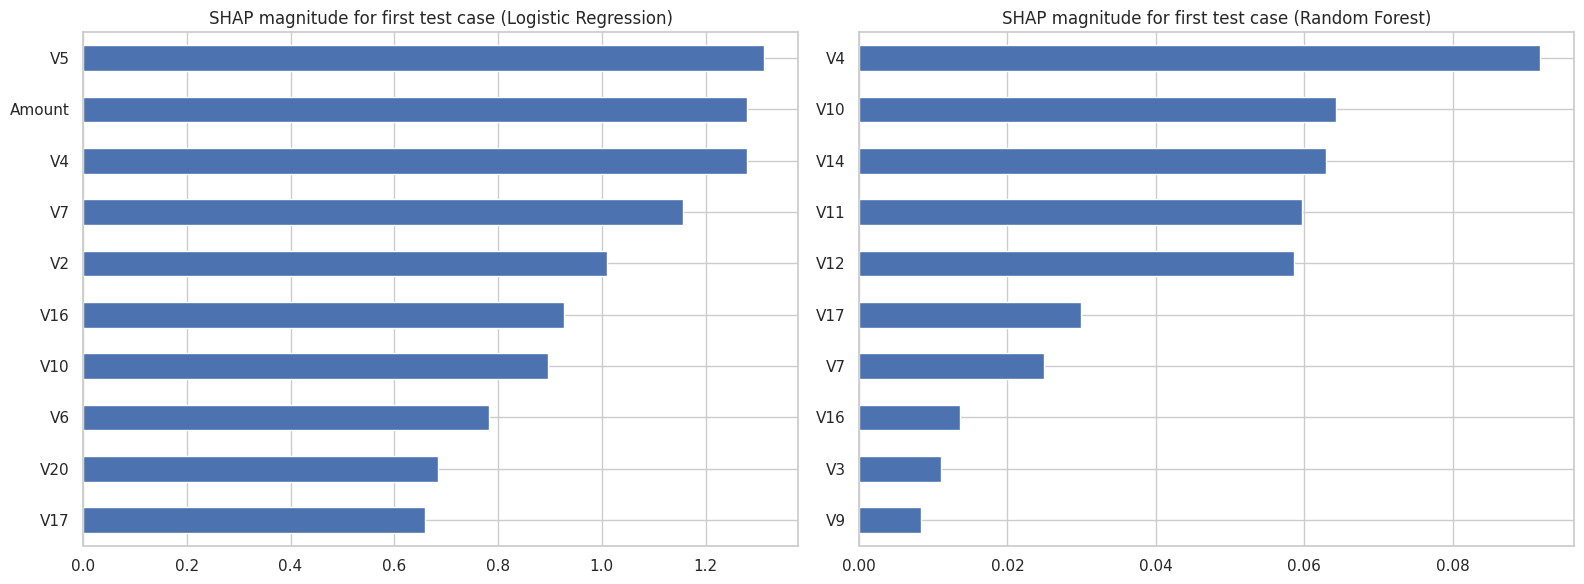

In [237]:
def _positive_class_shap(shap_output):
    # Normalize SHAP outputs so we always work with class-1 contributions.
    if isinstance(shap_output, list):
        return shap_output[1] if len(shap_output) > 1 else shap_output[0]

    shap_arr = np.asarray(shap_output)
    if shap_arr.ndim == 3 and shap_arr.shape[-1] == 2:
        return shap_arr[..., 1]

    return shap_output

# Use a smaller background/sample for speed and stability.
shap_bg_size = min(500, len(X_train))
shap_eval_size = min(500, len(X_test))

X_train_bg = X_train.sample(n=shap_bg_size, random_state=42)
X_test_sample = X_test.sample(n=shap_eval_size, random_state=42)
X_train_bg_scaled = scaler.transform(X_train_bg)
X_test_sample_scaled = scaler.transform(X_test_sample)

# Linear model SHAP values (on scaled features)
lr_explainer = shap.LinearExplainer(lr_model, X_train_bg_scaled)
lr_shap_raw = lr_explainer.shap_values(X_test_sample_scaled)
lr_shap_values = _positive_class_shap(lr_shap_raw)

# Random forest SHAP values (on original features)
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_raw = rf_explainer.shap_values(X_test_sample)
rf_shap_values = _positive_class_shap(rf_shap_raw)

# Global importance view
plt.figure(figsize=(9, 6))
shap.summary_plot(lr_shap_values, X_test_sample_scaled, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP: Logistic Regression (global importance)")
plt.tight_layout()
save_fig("shap_global_lr.png")
plt.show()

plt.figure(figsize=(9, 6))
shap.summary_plot(rf_shap_values, X_test_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP: Random Forest (global importance)")
plt.tight_layout()
save_fig("shap_global_rf.png")
plt.show()

# Local explanations for the two test cases already selected above
case_scaled = scaler.transform(test_case_features)
lr_case_shap_raw = lr_explainer.shap_values(case_scaled)
lr_case_shap = _positive_class_shap(lr_case_shap_raw)
rf_case_shap_raw = rf_explainer.shap_values(test_case_features)
rf_case_shap = _positive_class_shap(rf_case_shap_raw)

for i, case_name in enumerate(test_case_features.index):
    print(f"\n=== SHAP explanation for {case_name} ===")
    print(f"Actual class: {int(test_case_labels.iloc[i])}")
    print(f"Logistic regression probability: {lr_case_probs[i]:.6f}")
    print(f"Random forest probability: {rf_case_probs[i]:.6f}")

    case_series = pd.Series(test_case_features.iloc[i], index=feature_names)

    print("\nRaw feature values:")
    print(case_series.to_string())

    print("\nTop features by magnitude:")
    print(
        case_series.reindex(case_series.abs().sort_values(ascending=False).index)
        .head(10)
        .to_string()
    )

    lr_contrib = pd.Series(lr_case_shap[i], index=feature_names).sort_values()
    rf_contrib = pd.Series(rf_case_shap[i], index=feature_names).sort_values()

    print("\nLogistic regression: strongest pushes toward fraud")
    print(lr_contrib.tail(5).to_string())
    print("Logistic regression: strongest pushes away from fraud")
    print(lr_contrib.head(5).to_string())

    print("\nRandom forest: strongest pushes toward fraud")
    print(rf_contrib.tail(5).to_string())
    print("Random forest: strongest pushes away from fraud")
    print(rf_contrib.head(5).to_string())

# A quick visual for the first test case in each model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
case_0_lr = pd.Series(lr_case_shap[0], index=feature_names).abs().sort_values().tail(10)
case_0_rf = pd.Series(rf_case_shap[0], index=feature_names).abs().sort_values().tail(10)

case_0_lr.plot(kind="barh", ax=axes[0], title="SHAP magnitude for first test case (Logistic Regression)")
case_0_rf.plot(kind="barh", ax=axes[1], title="SHAP magnitude for first test case (Random Forest)")
plt.tight_layout()
save_fig("shap_local_case0.png")
plt.show()

## Save any remaining open figures

In [238]:
# Save any remaining open matplotlib figures that have not already been written to disk.
for i, num in enumerate(plt.get_fignums(), start=1):
    fig = plt.figure(num)
    fig.savefig(os.path.join(OUTPUT_DIR, f"open_figure_{i}.png"), bbox_inches="tight", dpi=300)

print(f"Saved open figures to {OUTPUT_DIR}")

Saved open figures to model_outputs
